<a href="https://colab.research.google.com/github/RoihansLab/Machine-Learning-Projects/blob/main/10_End_to_End_Retail_Demand_Forecasting/10_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Machine Learning Model for 10_End_to_End_Retail_Demand_Forecasting.**

## **1. Import Libraries Module**

In [45]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

from xgboost import XGBRegressor
import optuna
import pickle

## **2. Load the Datasets**

In [46]:
df = pd.read_csv("/content/demand_forecasting.csv")
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,Snowy,0,32.23,Winter,0,64
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,Snowy,0,40.73,Winter,0,137
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,Snowy,0,19.41,Winter,0,68
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,Snowy,0,143.71,Winter,0,84


In [47]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand'],
      dtype='object')

## **3. Feature Selection**

dikarenakan kita sudah melihat bahwa yang paling mempengaruhi **Demand** adalah Price, Competitor Pricing, Discount Inventory Level, Category dan Promotion, kita mulai mengambil feature untuk persiapan train and test

In [48]:
feature = [
    "Price",
    "Competitor Pricing",
    "Discount",
    "Inventory Level",
    "Category",
    "Promotion"
]

feature

['Price',
 'Competitor Pricing',
 'Discount',
 'Inventory Level',
 'Category',
 'Promotion']

In [49]:
feature

['Price',
 'Competitor Pricing',
 'Discount',
 'Inventory Level',
 'Category',
 'Promotion']

In [50]:
target = "Demand"

In [51]:
X = df[feature].copy()
X

,Price,Competitor Pricing,Discount,Inventory Level,Category,Promotion
0,72.72,85.73,5,195,Electronics,0
1,80.16,92.02,15,117,Clothing,1
2,62.94,60.08,10,247,Clothing,1
3,87.63,85.19,10,139,Electronics,0
4,54.41,51.63,0,152,Groceries,0
...,...,...,...,...,...,...
75995,29.80,32.23,5,233,Toys,0
75996,42.92,40.73,5,137,Toys,0
75997,17.81,19.41,10,197,Clothing,0
75998,151.72,143.71,0,125,Furniture,0


In [52]:
y = df[target]
y

,Demand
0,115
1,229
2,157
3,52
4,59
...,...
75995,64
75996,137
75997,68
75998,84


## **4. Feature Encoding**

Feature encoding is performed to transform categorical variables (text-based data) into numerical formats so that machine learning algorithms can properly read, process, and train on the dataset.

In [53]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand'],
      dtype='object')

In [54]:
le_category = LabelEncoder()
X["Category"]= le_category.fit_transform(X["Category"])

X

,Price,Competitor Pricing,Discount,Inventory Level,Category,Promotion
0,72.72,85.73,5,195,1,0
1,80.16,92.02,15,117,0,1
2,62.94,60.08,10,247,0,1
3,87.63,85.19,10,139,1,0
4,54.41,51.63,0,152,3,0
...,...,...,...,...,...,...
75995,29.80,32.23,5,233,4,0
75996,42.92,40.73,5,137,4,0
75997,17.81,19.41,10,197,0,0
75998,151.72,143.71,0,125,2,0


## **5. Train, Test and Spliting Data**

Dividing the preprocessed data into training and testing sets (using an 80:20 ratio with a fixed random state). This ensures the model learns patterns from the training split without data leakage, allowing for an unbiased evaluation on the test split.

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [56]:
X_train.shape , y_train.shape

((60800, 6), (60800,))

In [57]:
X_test.shape, y_test.shape

((15200, 6), (15200,))

## **6. Modelling**

In [58]:
xgb = XGBRegressor(objective="reg:squarederror", n_jobs = -1 , random_state=42)

## **7. Hyperparameter Tuning (Randomized Search)**

To optimize the XGBoost model's performance without exhaustive computational costs, we utilize `RandomizedSearchCV`. This approach randomly samples a defined hyperparameter space (`param_dict`) over multiple iterations (`n_trials=25` across 3-fold cross-validation) to locate the optimal configuration of parameters:

- **`n_estimators`**: Number of boosting rounds (trees built).
- **`max_depth`**: Maximum depth of trees to control model complexity and prevent overfitting.
- **`learning_rate`**: Step-size shrinkage used to update feature weights and stabilize learning.
- **`subsample` & `colsample_bytree`**: Fraction of samples and features randomly sampled per tree to introduce stochasticity and reduce overfitting.
- **`min_child_weight`**: Minimum sum of instance weight needed in a child, acting as a structural regularizer.

In [59]:
param_dict = {
    "n_estimators" : [200, 300, 500],
    "max_depth" : [3, 4, 6, 8],
    "learning_rate" : [0.01, 0.02, 0.1],
    "subsample" : [0.7, 0.8, 1.0],
    "colsample_bytree" : [0.7, 0.8, 1.0],
    "min_child_weight" : [1, 3, 5],
}

In [60]:
random_search = RandomizedSearchCV(
    estimator = xgb,
    param_distributions = param_dict,
    n_iter = 25,
    scoring = "neg_mean_squared_error",
    cv = 3,
    verbose = 1,
    n_jobs = -1
)

now we training the model

In [61]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=True,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints...
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=-1,
                                          num_parallel_tree=None, ...),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.02, 0.1],
                                        'max_depth': [3, 4, 6, 8],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [200, 300, 500],
                                        'subsample': [0.7, 0.8, 1.0]},
                   scoring='neg_mean_squared_error', verbose=1)

best parameter we got

In [62]:
random_search.best_params_

{'subsample': 1.0,
 'n_estimators': 500,
 'min_child_weight': 5,
 'max_depth': 8,
 'learning_rate': 0.02,
 'colsample_bytree': 1.0}

In [63]:
best_model = random_search.best_estimator_

In [73]:
# 1. Usir paksa dua kolom siluman kalau mereka masih nempel di X_test
X_test = X_test.drop(columns=['Predicted Demand', 'Actual Demand'], errors='ignore')

# 2. Baru hajar tebakannya!
y_pred = best_model.predict(X_test)

# 3. Tampilin biar lu yakin y_pred-nya beneran udah ada isinya
print("Berhasil nebak! Ini 10 hasil tebakan pertamanya:", y_pred[:10])

Berhasil nebak! Ini 10 hasil tebakan pertamanya: [ 83.24197   70.33295   35.101326 105.65526   78.09798   98.86677
 107.79965  114.92841  137.52849  134.36053 ]


## **8. Comparing Actual and Predict result**

In [65]:
# Bikin tabel perbandingan Asli vs Prediksi
hasil_df = pd.DataFrame({
    "Kenyataan (Actual)": y_test,
    "Tebakan (Predicted)": y_pred.round() # Dibulatkan, karena Demand barang nggak mungkin koma
})

# Liat 10 baris pertama
print(hasil_df.head(10))

       Kenyataan (Actual)  Tebakan (Predicted)
53731                 111                 83.0
61112                  81                 70.0
72074                  37                 35.0
56928                 152                106.0
20979                 101                 78.0
59697                 137                 99.0
51092                 127                108.0
70258                 163                115.0
51086                 164                138.0
1768                  111                134.0


## **9. Visualized**

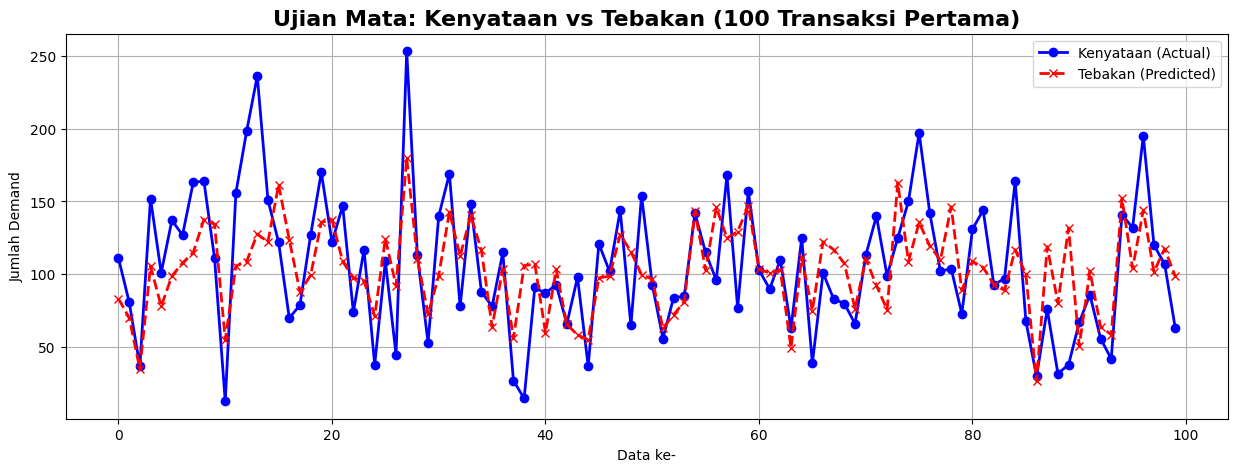

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

# Bikin garis biru buat Kenyataan, garis merah putus-putus buat Tebakan
plt.plot(y_test.values[:100], label="Kenyataan (Actual)", color="blue", marker="o", linewidth=2)
plt.plot(y_pred[:100], label="Tebakan (Predicted)", color="red", linestyle="dashed", marker="x", linewidth=2)

plt.title("Ujian Mata: Kenyataan vs Tebakan (100 Transaksi Pertama)", fontsize=16, fontweight="bold")
plt.ylabel("Jumlah Demand")
plt.xlabel("Data ke-")
plt.legend()
plt.grid(True)
plt.show()

## **10. Good Fit?**

In [67]:
# 1. Suruh mesin nebak ulang soal latihannya (Data Training)
y_pred_train = best_model.predict(X_train)

# 2. Hitung metrik tambahan (RMSE & MAPE) buat Latihan dan Ujian
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))

mape_train = mean_absolute_percentage_error(y_train, y_pred_train)
mape_test = mean_absolute_percentage_error(y_test, y_pred)

# 3. Cetak Laporan Kasta Mesin Lengkap (4 Metrik)
print("=== 📊 CEK KASTA MESIN LU: JAGO KANDANG ATAU NGGAK? ===")

# R2 Score (Akurasi - Bahasa Mesin)
print(f"R2 Score (Data Latihan/Train) : {r2_score(y_train, y_pred_train):.3f}")
print(f"R2 Score (Data Ujian/Test)    : {r2_score(y_test, y_pred):.3f}")
print("-" * 55)

# MAE (Bahasa Bos Gudang)
print(f"MAE Latihan (Train)           : Meleset {mean_absolute_error(y_train, y_pred_train):.2f} pcs")
print(f"MAE Ujian (Test)              : Meleset {mean_absolute_error(y_test, y_pred):.2f} pcs")
print("-" * 55)

# RMSE (Hukuman Outlier)
print(f"RMSE Latihan (Train)          : {rmse_train:.2f} pcs")
print(f"RMSE Ujian (Test)             : {rmse_test:.2f} pcs")
print("-" * 55)

# MAPE (Bahasa Direktur)
print(f"MAPE Latihan (Train)          : Meleset {mape_train * 100:.2f}%")
print(f"MAPE Ujian (Test)             : Meleset {mape_test * 100:.2f}%")

=== 📊 CEK KASTA MESIN LU: JAGO KANDANG ATAU NGGAK? ===
R2 Score (Data Latihan/Train) : 0.504
R2 Score (Data Ujian/Test)    : 0.428
-------------------------------------------------------
MAE Latihan (Train)           : Meleset 25.06 pcs
MAE Ujian (Test)              : Meleset 26.99 pcs
-------------------------------------------------------
RMSE Latihan (Train)          : 33.06 pcs
RMSE Ujian (Test)             : 35.55 pcs
-------------------------------------------------------
MAPE Latihan (Train)          : Meleset 36.43%
MAPE Ujian (Test)             : Meleset 38.88%


## **11. Feature Importance**

In [68]:
best_model.feature_importances_

array([0.05929114, 0.01697148, 0.01511611, 0.01283041, 0.24198541,
       0.65380543], dtype=float32)

In [69]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance

,0
Promotion,0.653805
Category,0.241985
Price,0.059291
Competitor Pricing,0.016971
Discount,0.015116
Inventory Level,0.012830


<Axes: title={'center': 'Feature Importance'}>

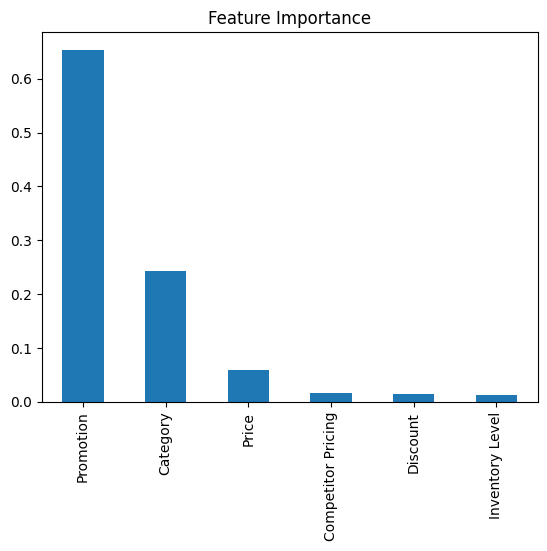

In [70]:
feature_importance.plot(kind="bar", title = "Feature Importance"
)

## **12. Save Model and Label Encoder**

In [71]:
# Pastikan library pickle udah di-import (lu sebenernya udah import di awal)
import pickle

# 1. Buka file baru dengan nama 'xgboost_demand_model.pkl' pakai mode 'wb' (Write Binary)
with open('xgboost_demand_model_RSCV.pkl', 'wb') as file:
    # 2. Masukin otak mesin lu (best_model) ke dalam file itu
    pickle.dump(best_model, file)

print("🔥 Otak XGBoost lu berhasil dibungkus jadi .pkl! Cek tab 'Files' (ikon folder) di sebelah kiri Colab lu.")

🔥 Otak XGBoost lu berhasil dibungkus jadi .pkl! Cek tab 'Files' (ikon folder) di sebelah kiri Colab lu.


In [72]:
# 1. Buka file baru khusus buat Label Encoder
with open('label_encoder_category.pkl', 'wb') as file:
    # 2. Masukin si 'le_category' ke dalam file
    pickle.dump(le_category, file)

print("✅ Label Encoder (le_category) berhasil dibungkus jadi .pkl! Amunisi udah komplit!")

✅ Label Encoder (le_category) berhasil dibungkus jadi .pkl! Amunisi udah komplit!
